In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [26]:
# CSV file path in Google Drive
# file_path = '/content/drive/MyDrive/Dataset/DigitalExposome Dataset.csv'
file_path = '../DigitalExposome Dataset.csv'
# Load dataset using Pandas
df = pd.read_csv(file_path)

# Display the top 5 rows of the dataset
df.head()

,IBI,HR,NO2,Noise,NH3,PM10,CO,PM25,Label,PM1,EDA,BVP
0,0.0,0.377574,0.0,0.511358,0.003018,0.003091,0.871758,0.000000,5,0.000000,0.0,0.0
1,0.0,0.196398,0.0,0.490903,0.003018,0.003091,0.876848,0.003091,5,0.001854,0.0,0.0
2,0.0,0.454163,0.0,0.470449,0.006036,0.006181,0.881939,0.006181,5,0.003709,0.0,0.0
3,0.0,0.322451,0.0,0.449995,0.009055,0.009272,0.887030,0.009272,5,0.005563,0.0,0.0
4,0.0,0.237595,0.0,0.429540,0.012073,0.012362,0.892121,0.012362,5,0.007417,0.0,0.0


In [27]:
df.describe()

,IBI,HR,NO2,Noise,NH3,PM10,CO,PM25,Label,PM1,EDA,BVP
count,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000
mean,0.178688,0.530687,0.502239,0.427541,0.564276,0.208474,0.679874,0.224901,3.326185,0.230773,0.260318,0.482902
std,0.230127,0.266531,0.274914,0.247601,0.294515,0.210981,0.308111,0.223242,1.599863,0.255253,0.221725,0.175569
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.309505,0.285412,0.214008,0.305285,0.017624,0.458047,0.012362,2.000000,0.006310,0.060686,0.449963
50%,0.016760,0.491213,0.489703,0.403671,0.644756,0.158454,0.805352,0.176150,4.000000,0.176316,0.216064,0.512280
75%,0.309984,0.776388,0.736983,0.618592,0.826943,0.326889,0.909832,0.376813,5.000000,0.407268,0.421109,0.579756
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,5.000000,24.000000,1.000000,1.000000


In [28]:
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (42436, 12)
Columns: Index(['IBI', 'HR', 'NO2', 'Noise', 'NH3', 'PM10', 'CO', 'PM25', 'Label',
       'PM1', 'EDA', 'BVP'],
      dtype='object')


# Check Data type

In [29]:
print("\nData Types:")
df.info()


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42436 entries, 0 to 42435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     42436 non-null  float64
 1   HR      42436 non-null  float64
 2   NO2     42436 non-null  float64
 3   Noise   42436 non-null  float64
 4   NH3     42436 non-null  float64
 5   PM10    42436 non-null  float64
 6   CO      42436 non-null  float64
 7   PM25    42436 non-null  float64
 8   Label   42436 non-null  int64  
 9   PM1     42436 non-null  float64
 10  EDA     42436 non-null  float64
 11  BVP     42436 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 3.9 MB


In [30]:
# cek missing value
df.isnull().sum()

IBI      0
HR       0
NO2      0
Noise    0
NH3      0
PM10     0
CO       0
PM25     0
Label    0
PM1      0
EDA      0
BVP      0
dtype: int64

In [31]:
# Duplicated
df.duplicated().sum()

14342

In [32]:
# Cek data NaN
df.isna().sum()

IBI      0
HR       0
NO2      0
Noise    0
NH3      0
PM10     0
CO       0
PM25     0
Label    0
PM1      0
EDA      0
BVP      0
dtype: int64

In [33]:
# Jika ingin menghapus duplikat tanpa menimpa df lama
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28094 entries, 0 to 38158
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     28094 non-null  float64
 1   HR      28094 non-null  float64
 2   NO2     28094 non-null  float64
 3   Noise   28094 non-null  float64
 4   NH3     28094 non-null  float64
 5   PM10    28094 non-null  float64
 6   CO      28094 non-null  float64
 7   PM25    28094 non-null  float64
 8   Label   28094 non-null  int64  
 9   PM1     28094 non-null  float64
 10  EDA     28094 non-null  float64
 11  BVP     28094 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 2.8 MB


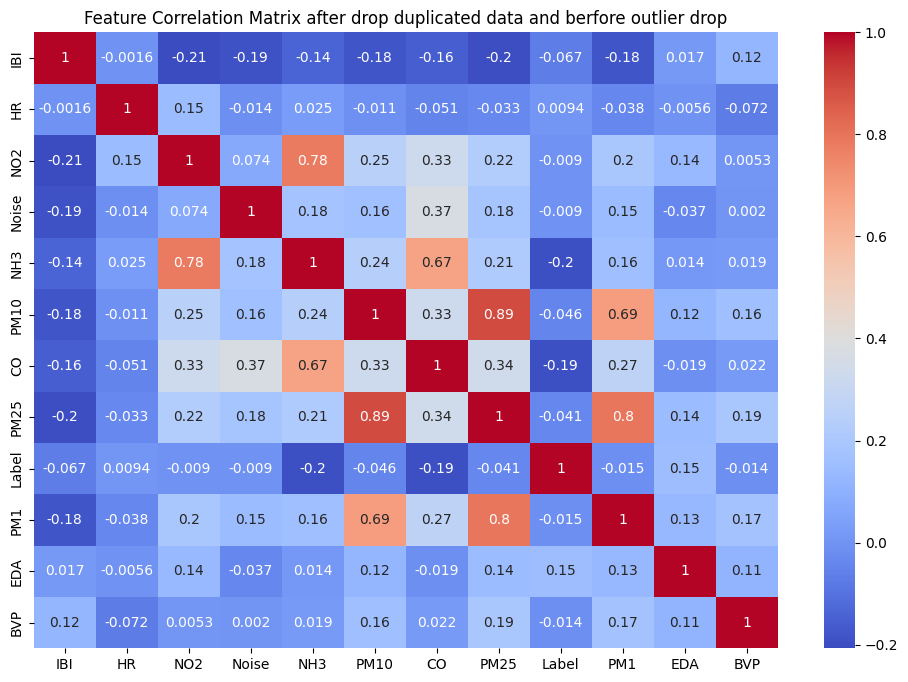

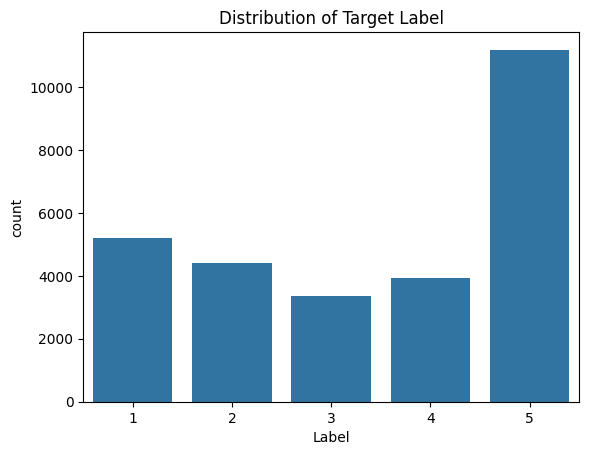

In [34]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix after drop duplicated data and berfore outlier drop")
plt.show()

# Distribusi Label
sns.countplot(x='Label', data=df)
plt.title("Distribution of Target Label")
plt.show()

## Prepocessing

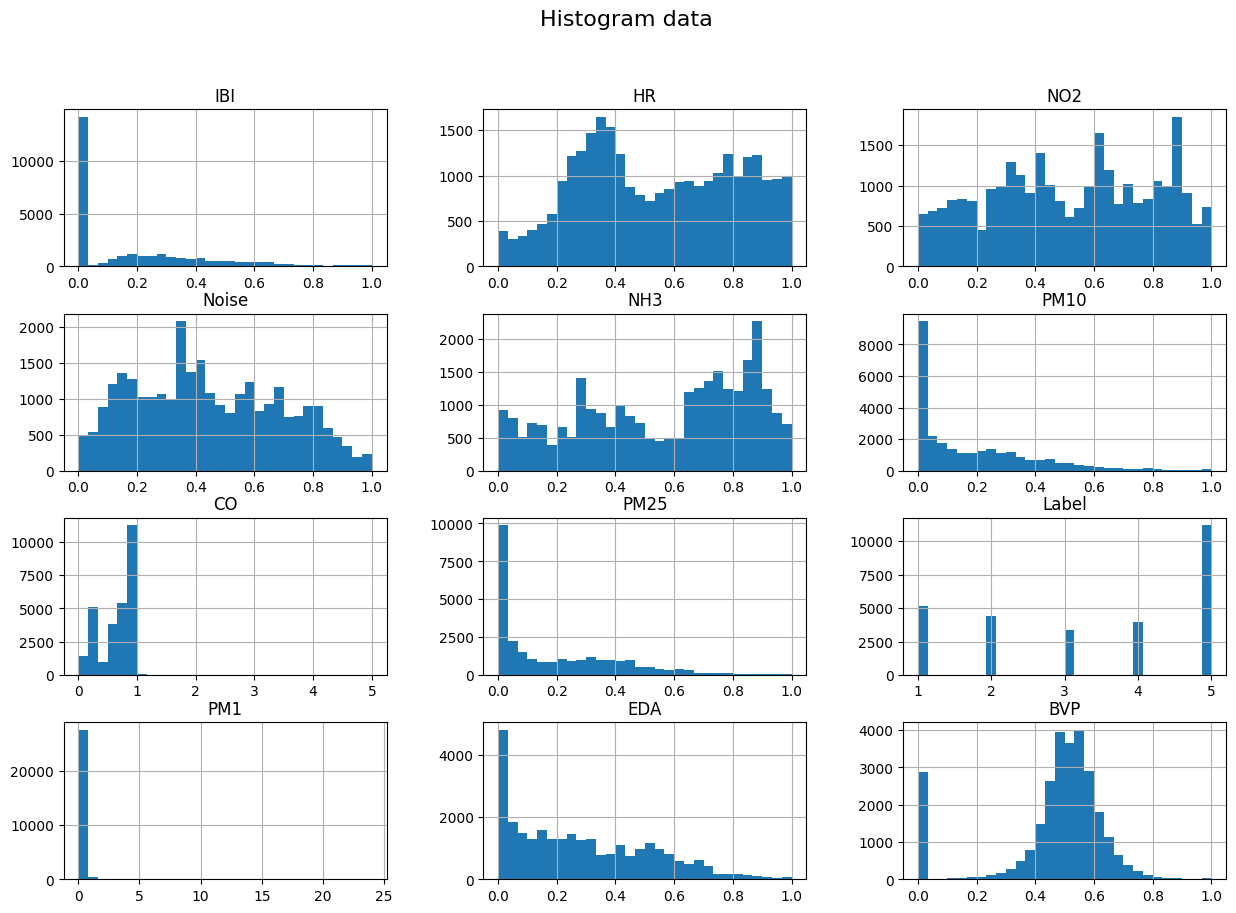

In [35]:
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram data", fontsize=16)
plt.show()

In [36]:
df.shape

(28094, 12)

/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_2142/3770775098.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/Users/muhammadzuamaalamin/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


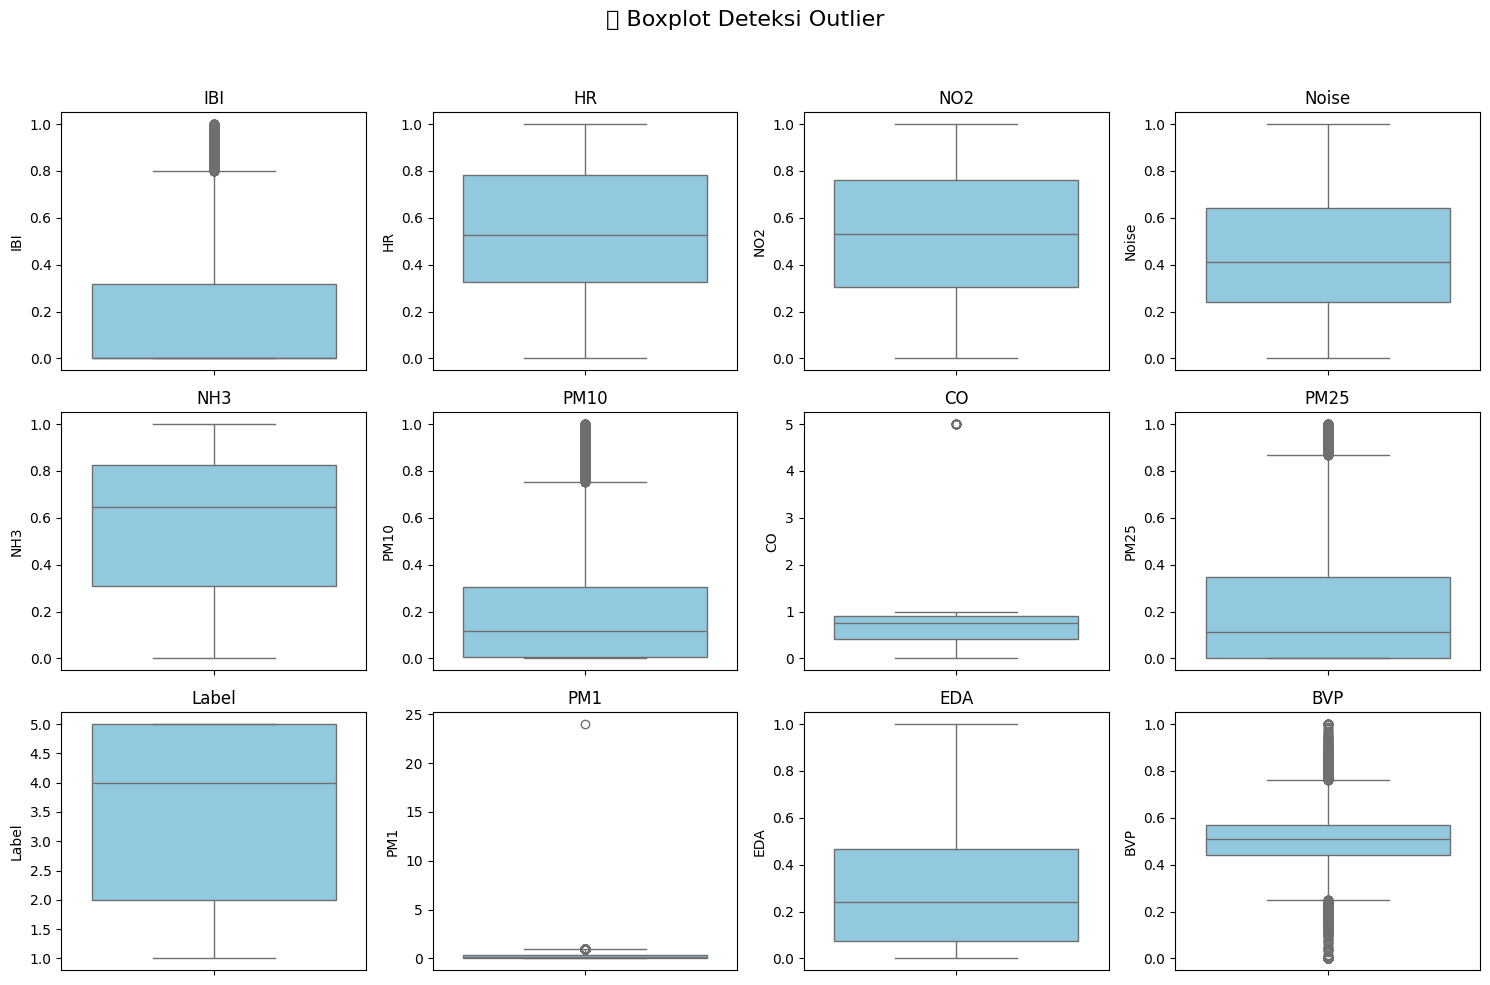

In [37]:
# Simpan salinan data sebelum outlier removal (untuk visualisasi)
df_before_outlier = df.copy()
import matplotlib.pyplot as plt
import seaborn as sns

# Buat grid layout otomatis sesuai jumlah kolom
n_cols = 4  # jumlah boxplot per baris
n_rows = -(-len(df.columns) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()  # supaya bisa diiterasi

for i, col in enumerate(df.columns):
    sns.boxplot(y=df_before_outlier[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f"{col}")

# Hapus axis kosong kalau jumlah kolom tidak pas
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("📊 Boxplot Deteksi Outlier", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [38]:
# Memisahkan fitur (X) dan label (y)
X = df.drop('Label', axis=1)
y = df['Label']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (28094, 11)
Shape of target (y): (28094,)


In [39]:
print(X.info())
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 28094 entries, 0 to 38158
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     28094 non-null  float64
 1   HR      28094 non-null  float64
 2   NO2     28094 non-null  float64
 3   Noise   28094 non-null  float64
 4   NH3     28094 non-null  float64
 5   PM10    28094 non-null  float64
 6   CO      28094 non-null  float64
 7   PM25    28094 non-null  float64
 8   PM1     28094 non-null  float64
 9   EDA     28094 non-null  float64
 10  BVP     28094 non-null  float64
dtypes: float64(11)
memory usage: 2.6 MB
None
Label
5    11184
1     5193
2     4408
4     3938
3     3371
Name: count, dtype: int64


## Prepocessing

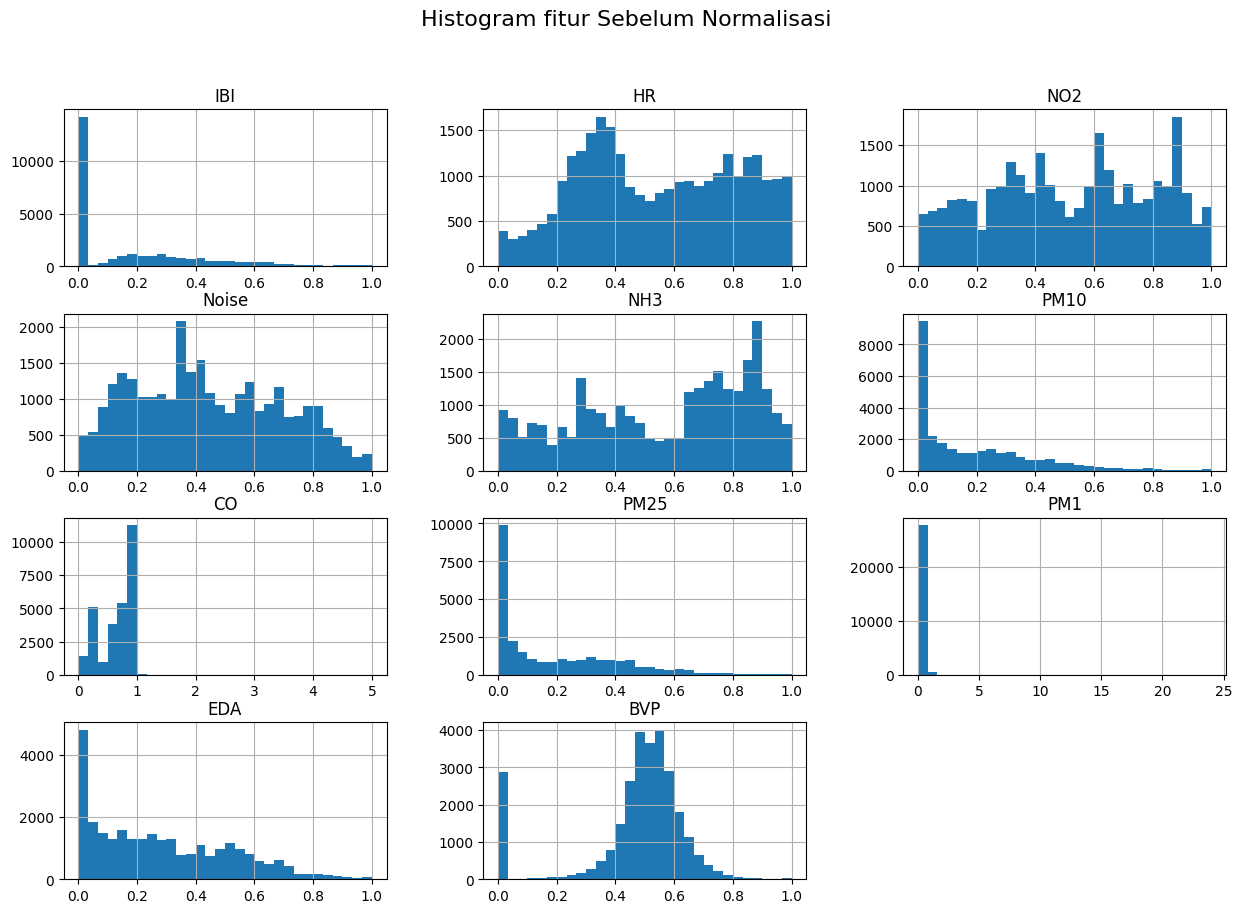

In [40]:
# Histogram sebelum normalisasi
X.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram fitur Sebelum Normalisasi", fontsize=16)
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
# Split data menjadi 80% data train dan 20% data test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data Train after normalisation = {X_train_scaled.shape}")
print(f"Data Test after normalisation = {X_test_scaled.shape}")

Data Train after normalisation = (22475, 11)
Data Test after normalisation = (5619, 11)


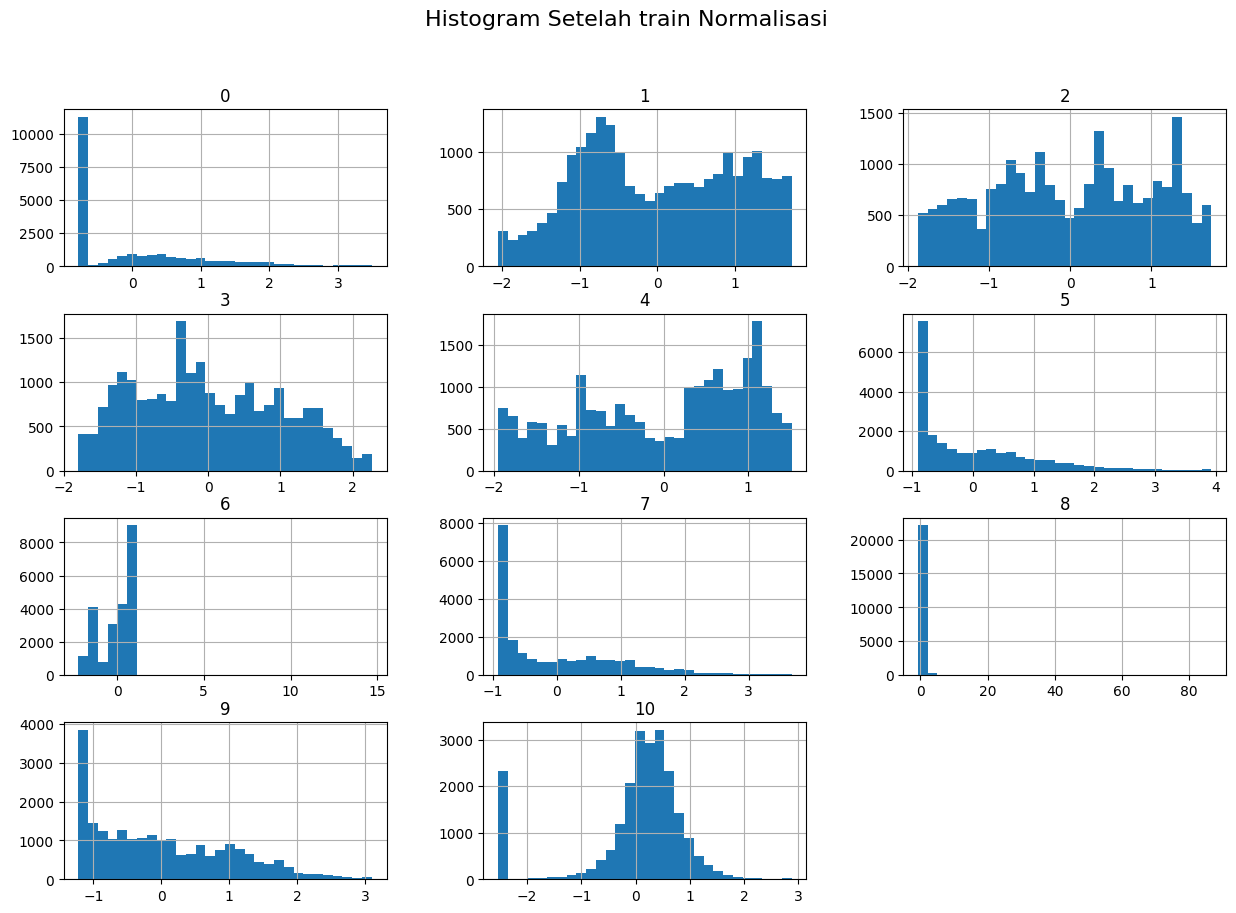

In [43]:
# Histogram setelah normalisasi
X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_train_scaled_df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram Setelah train Normalisasi", fontsize=16)
plt.show()

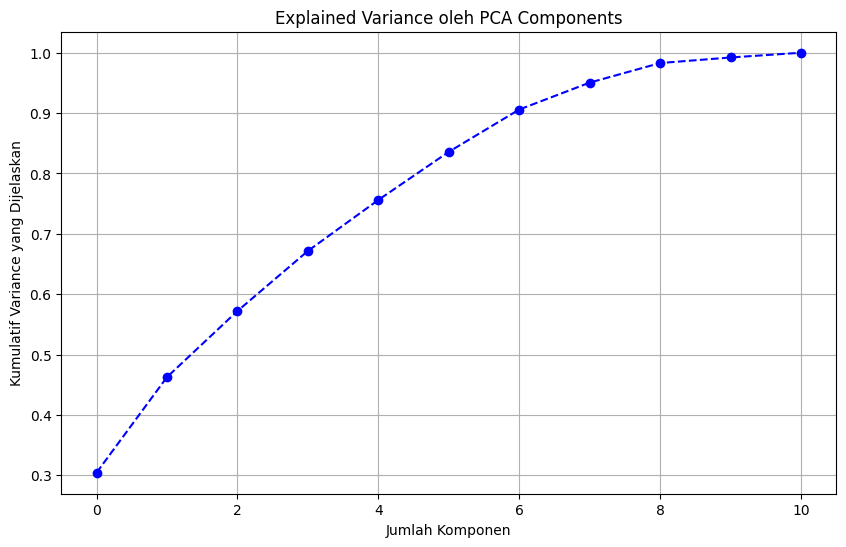

In [44]:
# Inisialisasi PCA tanpa mengurangi dimensi dulu (hanya untuk melihat explained variance)
pca = PCA(n_components=None) # Set n_components to None to keep all components initially
pca.fit(X_train_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Variance yang Dijelaskan')
plt.title('Explained Variance oleh PCA Components')
plt.grid(True)
plt.show()

In [45]:
# Tampilkan variansi kumulatif
explained_variance = np.cumsum(pca.explained_variance_ratio_)
for i, var in enumerate(explained_variance):
    print(f"Komponen ke-{i+1}: {var:.4f} variance terjelaskan")

# Misal ingin menyimpan komponen yang menjelaskan >=90% variance
n_components = np.argmax(explained_variance >= 0.90) + 1
print(f"\n🔍 Jumlah komponen optimal (≥90% variance): {n_components}")

Komponen ke-1: 0.3041 variance terjelaskan
Komponen ke-2: 0.4625 variance terjelaskan
Komponen ke-3: 0.5720 variance terjelaskan
Komponen ke-4: 0.6715 variance terjelaskan
Komponen ke-5: 0.7560 variance terjelaskan
Komponen ke-6: 0.8358 variance terjelaskan
Komponen ke-7: 0.9059 variance terjelaskan
Komponen ke-8: 0.9505 variance terjelaskan
Komponen ke-9: 0.9829 variance terjelaskan
Komponen ke-10: 0.9921 variance terjelaskan
Komponen ke-11: 1.0000 variance terjelaskan

🔍 Jumlah komponen optimal (≥90% variance): 7


In [46]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=7)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (22475, 7)
Shape test PCA: (5619, 7)


## Training Data

In [47]:
X_train

,IBI,HR,NO2,Noise,NH3,PM10,CO,PM25,PM1,EDA,BVP
2736,0.000000,0.502924,0.884615,0.425380,0.871605,0.141189,0.921888,0.174550,0.250500,0.495477,0.624732
4388,0.000000,0.633828,0.888889,0.763219,0.728067,0.388253,0.849677,0.526276,0.651391,0.709270,0.533895
27936,0.131613,0.785830,0.052902,0.240537,0.130912,0.417813,0.269516,0.417813,0.000000,0.086624,0.412167
30344,0.167950,0.569927,0.482524,0.050230,0.326058,0.000000,0.252824,0.000000,0.000000,0.262386,0.357681
12794,0.400379,0.032389,0.348705,0.555246,0.528364,0.162093,0.859388,0.287196,0.326454,0.168561,0.452616
...,...,...,...,...,...,...,...,...,...,...,...
24143,0.000000,0.434104,0.766266,0.154610,0.850842,0.000000,0.582371,0.000000,0.000000,0.421549,0.000000
5390,0.000000,0.792435,0.871658,0.669049,0.839488,0.145482,0.901095,0.274725,0.190325,0.005978,0.503365
860,0.000000,0.858015,0.648566,0.642042,0.541979,0.092715,0.332929,0.092715,0.061810,0.000000,0.000000
18363,0.582764,0.980634,0.158117,0.721833,0.472099,0.000000,0.786964,0.000000,0.000000,0.614349,0.580079


In [48]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_ann(X_train, X_test, y_train, y_test, percobaan="ANN_Full", output_file="results_ann.csv", epochs=30, batch_size=32):
    input_dim = X_train.shape[1]  # jumlah fitur

    # Normalisasi label supaya mulai dari 0
    unique_labels = np.unique(np.concatenate([y_train, y_test]))
    label_mapping = {old: new for new, old in enumerate(unique_labels)}
    y_train = np.array([label_mapping[y] for y in y_train])
    y_test = np.array([label_mapping[y] for y in y_test])

    n_classes = len(unique_labels)  # jumlah kelas sebenarnya
    
    # Definisi model ANN
    model = Sequential([
        Dense(128, activation="relu", input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax")  # output sesuai jumlah kelas
    ])
    
    # Kompilasi model
    model.compile(optimizer="adam", 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"])
    
    # Training
    history = model.fit(X_train, y_train, 
                        validation_data=(X_test, y_test),
                        epochs=epochs, 
                        batch_size=batch_size,
                        verbose=1)
    
    # Evaluasi
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    
    report = classification_report(y_test, y_pred_classes, output_dict=True)
    
    # Simpan hasil ke dataframe
    df_results = pd.DataFrame([{
        "Percobaan": percobaan,
        "Model": "ANN",
        "Accuracy": report["accuracy"],
        "Precision": report["macro avg"]["precision"],
        "Recall": report["macro avg"]["recall"],
        "F1-Score": report["macro avg"]["f1-score"]
    }])
    
    print("\n📊 Hasil Evaluasi ANN:")
    print(df_results)
    
    # Simpan ke CSV (append kalau sudah ada)
    try:
        existing = pd.read_csv(output_file)
        df_results = pd.concat([existing, df_results], ignore_index=True)
    except FileNotFoundError:
        pass
    df_results.to_csv(output_file, index=False)
    
    # Plot loss & akurasi
    plt.figure(figsize=(12,5))
    
    # Akurasi
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.show()
    
    return df_results, model


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Epoch 1/50
1405/1405 [==============================] - 1s 806us/step - loss: 1.3321 - accuracy: 0.4621 - val_loss: 1.2029 - val_accuracy: 0.5339
Epoch 2/50
1405/1405 [==============================] - 1s 744us/step - loss: 1.1772 - accuracy: 0.5357 - val_loss: 1.0865 - val_accuracy: 0.5739
Epoch 3/50
1405/1405 [==============================] - 1s 746us/step - loss: 1.0930 - accuracy: 0.5740 - val_loss: 1.0166 - val_accuracy: 0.6133
Epoch 4/50
1405/1405 [==============================] - 1s 786us/step - loss: 1.0516 - accuracy: 0.5971 - val_loss: 0.9771 - val_accuracy: 0.6371
Epoch 5/50
1405/1405 [==============================] - 1s 772us/step - loss: 1.0063 - accuracy: 0.6141 - val_loss: 0.9398 - val_accuracy: 0.6489
Epoch 6/50
1405/1405 [==============================] - 1s 743us/step - loss: 0.9736 - accuracy: 0.6283 - val_loss: 0.9033 - val_accuracy: 0.6658
Epoch 7/50
1405/1405 [==============================] - 1s 746us/step - loss: 0.9487 - accuracy: 0.6346 - val_loss: 0.8709 -

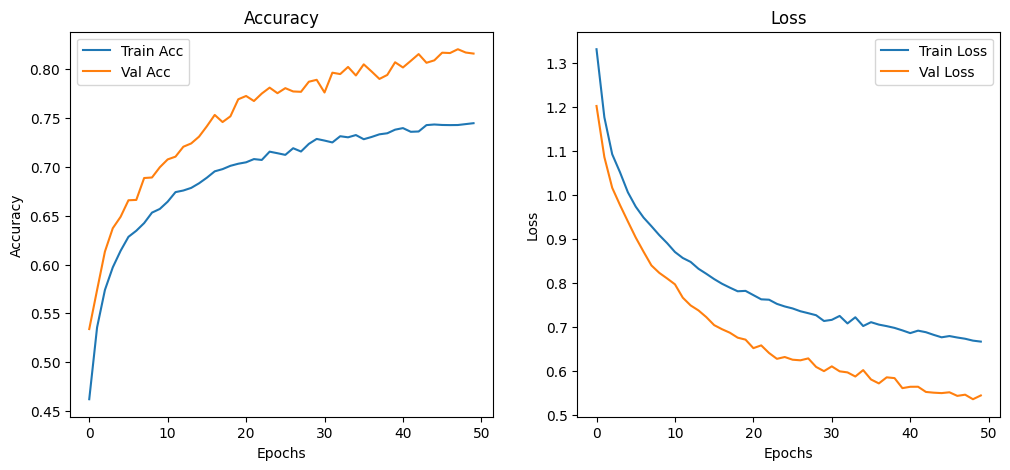

In [49]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train, X_test, y_train, y_test,
    percobaan="ANN Percobaan baseline imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)


Epoch 1/50
1405/1405 [==============================] - 1s 893us/step - loss: 1.2458 - accuracy: 0.5064 - val_loss: 1.0718 - val_accuracy: 0.5928
Epoch 2/50
1405/1405 [==============================] - 1s 771us/step - loss: 1.0963 - accuracy: 0.5759 - val_loss: 0.9723 - val_accuracy: 0.6318
Epoch 3/50
1405/1405 [==============================] - 1s 822us/step - loss: 1.0178 - accuracy: 0.6072 - val_loss: 0.9068 - val_accuracy: 0.6604
Epoch 4/50
1405/1405 [==============================] - 1s 776us/step - loss: 0.9716 - accuracy: 0.6229 - val_loss: 0.8630 - val_accuracy: 0.6716
Epoch 5/50
1405/1405 [==============================] - 1s 748us/step - loss: 0.9340 - accuracy: 0.6384 - val_loss: 0.8261 - val_accuracy: 0.6930
Epoch 6/50
1405/1405 [==============================] - 1s 841us/step - loss: 0.9073 - accuracy: 0.6493 - val_loss: 0.7930 - val_accuracy: 0.6971
Epoch 7/50
1405/1405 [==============================] - 1s 775us/step - loss: 0.8804 - accuracy: 0.6609 - val_loss: 0.7698 -

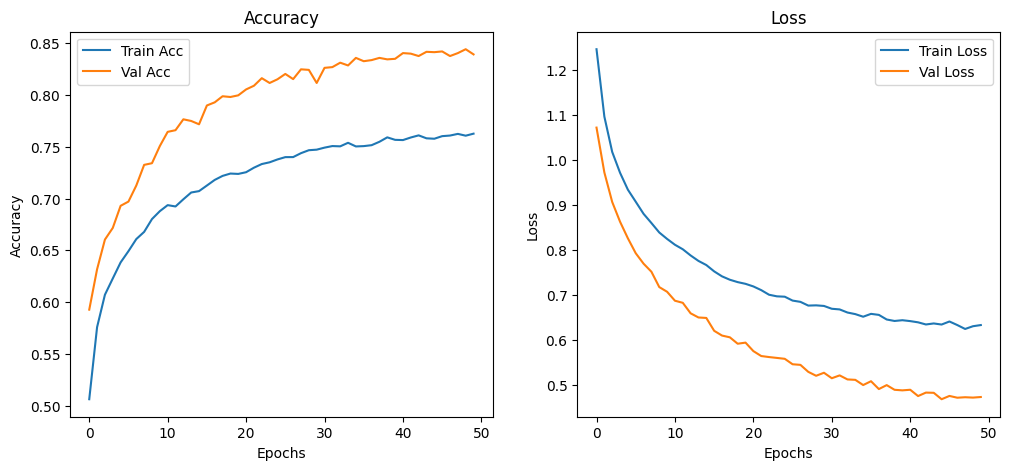

In [50]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train_scaled, X_test_scaled, y_train, y_test,
    percobaan="ANN Percobaan normalisasi imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)


In [51]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 8 komponen
pca = PCA(n_components=8)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (22475, 8)
Shape test PCA: (5619, 8)


Epoch 1/50
1405/1405 [==============================] - 1s 902us/step - loss: 1.2455 - accuracy: 0.5072 - val_loss: 1.0742 - val_accuracy: 0.6021
Epoch 2/50
1405/1405 [==============================] - 1s 845us/step - loss: 1.1024 - accuracy: 0.5713 - val_loss: 0.9880 - val_accuracy: 0.6240
Epoch 3/50
1405/1405 [==============================] - 1s 786us/step - loss: 1.0369 - accuracy: 0.5973 - val_loss: 0.9328 - val_accuracy: 0.6473
Epoch 4/50
1405/1405 [==============================] - 1s 852us/step - loss: 0.9959 - accuracy: 0.6114 - val_loss: 0.8868 - val_accuracy: 0.6592
Epoch 5/50
1405/1405 [==============================] - 1s 771us/step - loss: 0.9659 - accuracy: 0.6253 - val_loss: 0.8663 - val_accuracy: 0.6708
Epoch 6/50
1405/1405 [==============================] - 1s 823us/step - loss: 0.9464 - accuracy: 0.6365 - val_loss: 0.8237 - val_accuracy: 0.6836
Epoch 7/50
1405/1405 [==============================] - 1s 797us/step - loss: 0.9163 - accuracy: 0.6442 - val_loss: 0.7969 -

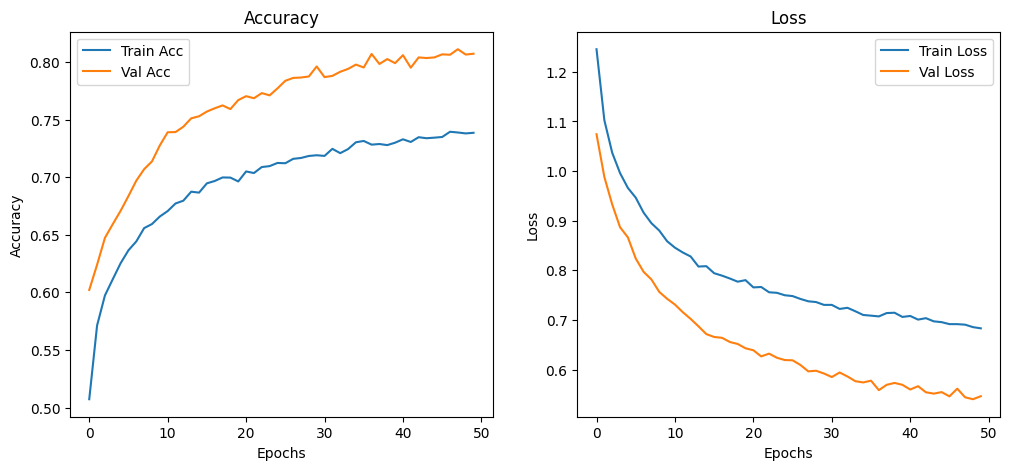

In [52]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train_pca, X_test_pca, y_train, y_test,
    percobaan="ANN Percobaan pca 8 imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)


In [53]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=7)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (22475, 7)
Shape test PCA: (5619, 7)


Epoch 1/50
1405/1405 [==============================] - 1s 866us/step - loss: 1.2621 - accuracy: 0.4976 - val_loss: 1.1110 - val_accuracy: 0.5750
Epoch 2/50
1405/1405 [==============================] - 1s 835us/step - loss: 1.1393 - accuracy: 0.5547 - val_loss: 1.0388 - val_accuracy: 0.5996
Epoch 3/50
1405/1405 [==============================] - 1s 770us/step - loss: 1.0829 - accuracy: 0.5815 - val_loss: 0.9890 - val_accuracy: 0.6183
Epoch 4/50
1405/1405 [==============================] - 1s 767us/step - loss: 1.0441 - accuracy: 0.5936 - val_loss: 0.9460 - val_accuracy: 0.6416
Epoch 5/50
1405/1405 [==============================] - 1s 803us/step - loss: 1.0178 - accuracy: 0.6076 - val_loss: 0.9265 - val_accuracy: 0.6426
Epoch 6/50
1405/1405 [==============================] - 1s 784us/step - loss: 0.9845 - accuracy: 0.6211 - val_loss: 0.8911 - val_accuracy: 0.6670
Epoch 7/50
1405/1405 [==============================] - 1s 767us/step - loss: 0.9646 - accuracy: 0.6270 - val_loss: 0.8775 -

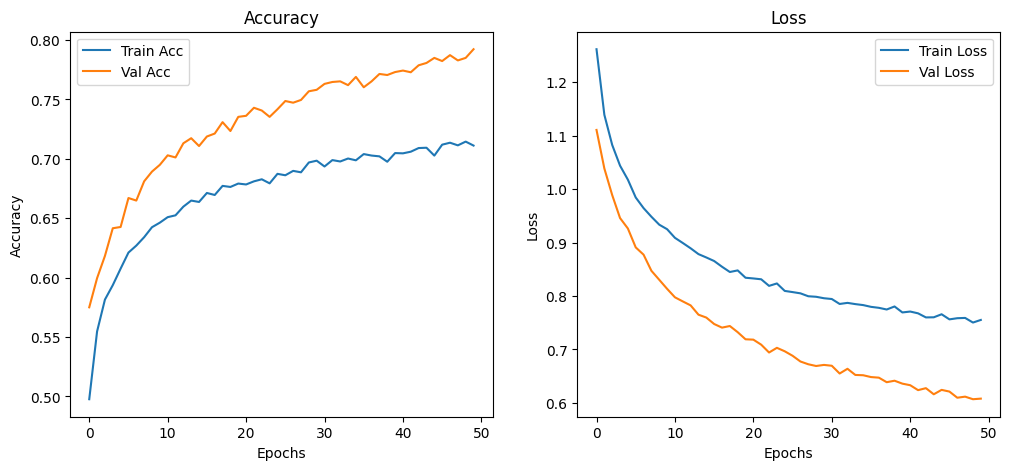

In [54]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train_pca, X_test_pca, y_train, y_test,
    percobaan="ANN Percobaan pca 7 imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)


In [55]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=6)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (22475, 6)
Shape test PCA: (5619, 6)


Epoch 1/50
1405/1405 [==============================] - 2s 958us/step - loss: 1.2813 - accuracy: 0.4933 - val_loss: 1.1351 - val_accuracy: 0.5791
Epoch 2/50
1405/1405 [==============================] - 1s 751us/step - loss: 1.1734 - accuracy: 0.5428 - val_loss: 1.0735 - val_accuracy: 0.5949
Epoch 3/50
1405/1405 [==============================] - 1s 770us/step - loss: 1.1259 - accuracy: 0.5612 - val_loss: 1.0250 - val_accuracy: 0.6079
Epoch 4/50
1405/1405 [==============================] - 1s 754us/step - loss: 1.0885 - accuracy: 0.5779 - val_loss: 0.9880 - val_accuracy: 0.6345
Epoch 5/50
1405/1405 [==============================] - 1s 782us/step - loss: 1.0683 - accuracy: 0.5853 - val_loss: 0.9726 - val_accuracy: 0.6384
Epoch 6/50
1405/1405 [==============================] - 1s 829us/step - loss: 1.0420 - accuracy: 0.5951 - val_loss: 0.9496 - val_accuracy: 0.6494
Epoch 7/50
1405/1405 [==============================] - 1s 761us/step - loss: 1.0246 - accuracy: 0.6039 - val_loss: 0.9269 -

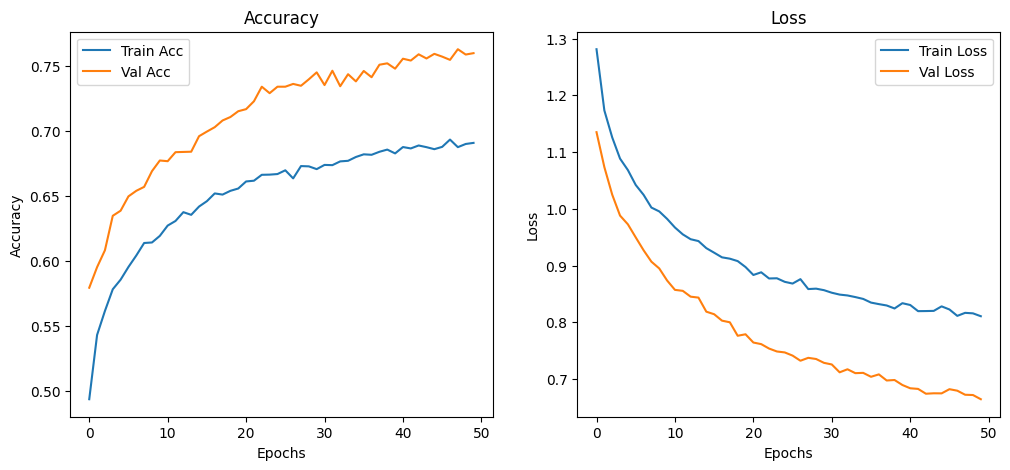

In [56]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train_pca, X_test_pca, y_train, y_test,
    percobaan="ANN Percobaan pca 6 imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)


In [57]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=5)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (22475, 5)
Shape test PCA: (5619, 5)


Epoch 1/50
1405/1405 [==============================] - 1s 761us/step - loss: 1.3264 - accuracy: 0.4697 - val_loss: 1.2025 - val_accuracy: 0.5312
Epoch 2/50
1405/1405 [==============================] - 1s 747us/step - loss: 1.2357 - accuracy: 0.5186 - val_loss: 1.1527 - val_accuracy: 0.5588
Epoch 3/50
1405/1405 [==============================] - 1s 726us/step - loss: 1.1984 - accuracy: 0.5286 - val_loss: 1.1053 - val_accuracy: 0.5788
Epoch 4/50
1405/1405 [==============================] - 1s 716us/step - loss: 1.1644 - accuracy: 0.5461 - val_loss: 1.0823 - val_accuracy: 0.5880
Epoch 5/50
1405/1405 [==============================] - 1s 714us/step - loss: 1.1385 - accuracy: 0.5547 - val_loss: 1.0621 - val_accuracy: 0.5974
Epoch 6/50
1405/1405 [==============================] - 1s 711us/step - loss: 1.1157 - accuracy: 0.5600 - val_loss: 1.0410 - val_accuracy: 0.5998
Epoch 7/50
1405/1405 [==============================] - 1s 737us/step - loss: 1.1055 - accuracy: 0.5648 - val_loss: 1.0185 -

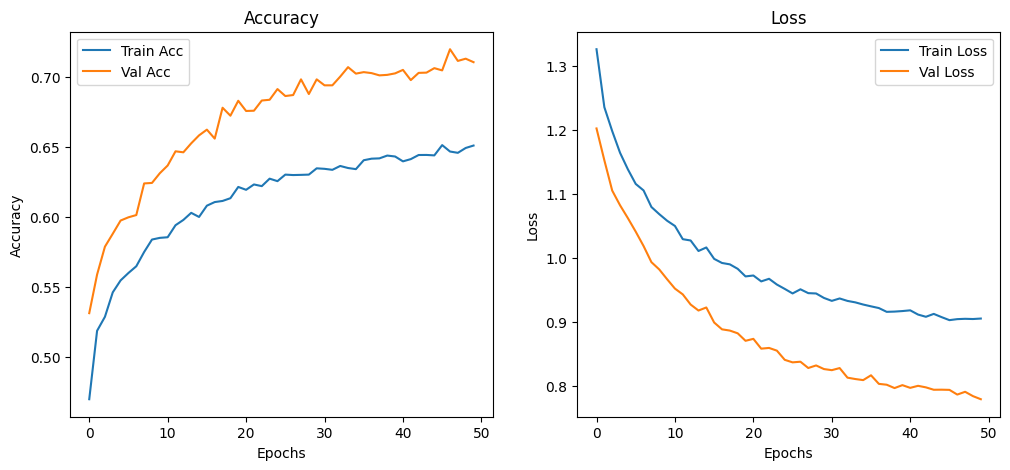

In [58]:
# Panggil fungsi evaluasi ANN
df_results, model = evaluate_ann(
    X_train_pca, X_test_pca, y_train, y_test,
    percobaan="ANN Percobaan pca 5 imbalance",  # bebas isi nama percobaan
    output_file="results_ann.csv", # file penyimpanan
    epochs=50,    # jumlah epoch
    batch_size=16 # ukuran batch
)
